# AI kunskapskontroll 2026 del 2

## EDA

## Börja med att ladda och beskriva data


In [1]:

import numpy as np # För numeriska operationer och arrayhantering
import pandas as pd # För datahantering och analys, särskilt med DataFrames
import matplotlib.pyplot as plt # För att skapa visualiseringar som grafer och diagram
import os # För att hantera filsystemet, t.ex. läsa och skriva filer
import joblib # För att spara och ladda modeller och andra Python-objekt effektivt

from sklearn.datasets import fetch_openml # Util lib För att hämta öppna datamängder, t.ex. MNIST
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,            # Total balanserad mått på hurpass korrekt modellen är vilket är TP+TN/Total
    precision_score,           # Hurpass korrekta är de positiva förutsägelserna, vilket är TP/TP+FP
    recall_score,              # Hurpass korrekta är de faktiska positiva förutsägelserna, vilket är TP/TP+FN
    f1_score,                  # Harmoniskt medelvärde av precision och recall
    classification_report,     # Textsammanfattning av precision/recall/F1/support per klass
    ConfusionMatrixDisplay,    # Verktyg för att visualisera förväxlingsmatrisens räkningar
    log_loss,                  # Straffar felaktigt förutsagda sannolikheter (lägre är bättre)
    top_k_accuracy_score,      # Sann etikett finns i modellens topp-k förutsägelser
    balanced_accuracy_score,   # Genomsnittlig recall över klasser (hanterar obalans bättre)
 )


In [2]:


# Externaliserar funktioner för att det ska var enkla att följa röda tråden
# Dessa funktioner är generella och kan återanvändas i andra projekt, så de är inte specifika för MNIST eller detta notebook.
def load_mnist():
    "Ladda Mnist, ""Load MNIST, print description and shape, return (X, y) with integer labels."""
    mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
    print(mnist.DESCR)
    print("Shape:", mnist.data.shape)
    return mnist.data, mnist.target.astype(int)

# Visualiseringsfunktioner
def plot_class_distribution(y, title="Klassfördelning", save_path="plots/class_distribution.png"):
    """Bar chart of class counts. Saves to file instead of displaying."""
    os.makedirs("plots", exist_ok=True)
    pd.Series(y).value_counts().sort_index().plot(kind="bar")
    plt.title(title)
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved to {save_path}")

# För att visualisera pixelintensitetsfördelningen över alla bilder i datasetet
def plot_pixel_distribution(X, title="Pixelintensitetsfördelning", bins=50, save_path="plots/pixel_distribution.png"):
    """Histogram of pixel intensities. Saves to file instead of displaying."""
    os.makedirs("plots", exist_ok=True)
    plt.figure()
    plt.hist(X.flatten(), bins=bins)
    plt.title(title)
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved to {save_path}")

# Genomsnittlig bild för varje siffra, visar typiska mönster och variationer inom klasserna.
def plot_average_digits(X, y, save_dir="plots"):
    """Show mean image for each unique class label. Saves to files instead of displaying."""
    os.makedirs(save_dir, exist_ok=True)
    for digit in np.unique(y):
        plt.figure(figsize=(4, 4))
        plt.imshow(X[y == digit].mean(axis=0).reshape(28, 28), cmap="gray")
        plt.title(f"Genomsnittlig siffra {digit}")
        save_path = f"{save_dir}/average_digit_{digit}.png"
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close()
        print(f"Saved to {save_path}")


def prepare_data(X, y, scale=True, test_size=0.2, random_state=42):
    """Optionally scale and split into train/test sets."""
    X_proc = X / 255.0 if scale else X
    return train_test_split(X_proc, y, test_size=test_size, random_state=random_state)


def train_logistic_regression(X_train, y_train, max_iter=1000, strategy="ovr"):
    """Train and return a Logistic Regression model with selected multiclass strategy."""
    if strategy == "ovr":
        base_model = LogisticRegression(max_iter=max_iter, solver="lbfgs")
        model = OneVsRestClassifier(base_model)
    elif strategy == "multinomial":
        model = LogisticRegression(max_iter=max_iter, solver="lbfgs", multi_class="multinomial")
    else:
        raise ValueError("strategy måste vara 'ovr' eller 'multinomial'")

    model.fit(X_train, y_train)
    return model


def train_or_load_svc(X_train, y_train, model_path='mnist_svc_model.joblib', kernel='rbf'):
    """Load SVC from disk if available, otherwise train and save it."""
    if os.path.exists(model_path):
        print("Loading SVC model from file...")
        return joblib.load(model_path)

    print("Training SVC model...")
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)

    # SVC är dyr att träna, så vi cachar modellen på disk.
    joblib.dump(model, model_path)
    print("SVC model saved to file.")
    return model


def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    """Build, compile and return a CNN model."""
    from tensorflow import keras
    from tensorflow.keras import layers

    model = keras.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Mnist_CNN")

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model


def train_cnn(model, X_train, y_train, image_shape=(28, 28, 1), epochs=10, batch_size=128, validation_split=0.2):
    """Reshape X_train and fit the CNN. Returns (history, X_train_reshaped)."""
    X_reshaped = X_train.reshape(-1, *image_shape)
    history = model.fit(
        X_reshaped,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=1,
    )
    return history, X_reshaped

In [3]:
# Funktioner för att utvärdera modeller med enhetliga metoder och visualiseringar
def evaluate_predictions(y_true, y_pred, name, y_proba=None, save_dir="plots"):
    """Compute and print a unified set of metrics for any classifier. Saves confusion matrix plot to file."""
    os.makedirs(save_dir, exist_ok=True)
    
    scores = {
        "modell": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_proba is not None:
        labels = np.unique(y_true)
        scores["log_loss"] = log_loss(y_true, y_proba, labels=labels)
        scores["top_3_accuracy"] = top_k_accuracy_score(y_true, y_proba, k=3, labels=labels)

    print(f"\n=== {name} ===")
    for key in ["accuracy", "f1_macro", "f1_weighted", "balanced_accuracy"]:
        print(f"{key}: {scores[key]:.4f}")
    if y_proba is not None:
        for key in ["log_loss", "top_3_accuracy"]:
            print(f"{key}: {scores[key]:.4f}")

    print("\nKlassificeringsrapport:")
    print(classification_report(y_true, y_pred, zero_division=0))

    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues", values_format="d")
    plt.title(f"Förvirringsmatris - {name}")
    
    # Spara plot istället för att visa det
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    save_path = f"{save_dir}/confusion_matrix_{safe_name}.png"
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved to {save_path}")

    return scores


def evaluate_sklearn_model(model, X_test, y_test, name):
    """Evaluate sklearn model with unified metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
    return evaluate_predictions(y_test, y_pred, name, y_proba=y_proba)


def evaluate_cnn(model, X_test, y_test, image_shape=(28, 28, 1), name="CNN"):
    """Evaluate CNN model with same metrics as sklearn models."""
    X_reshaped = X_test.reshape(-1, *image_shape)
    y_proba = model.predict(X_reshaped, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return evaluate_predictions(y_test, y_pred, name, y_proba=y_proba)

In [4]:

def evaluate_overfitting_sklearn(model, X_train, y_train, X_test, y_test, name):
    """Compare train vs test metrics to estimate overfitting for sklearn models. Uses English terminology."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    gap_acc = train_acc - test_acc
    gap_f1 = train_f1 - test_f1

    print(f"\n=== Överanpassningskontroll: {name} ===")
    print(f"train_accuracy: {train_acc:.4f} | test_accuracy: {test_acc:.4f} | gap: {gap_acc:.4f}")
    print(f"train_f1_macro: {train_f1:.4f} | test_f1_macro: {test_f1:.4f} | gap: {gap_f1:.4f}")

    return {
        "modell": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "gap_accuracy": gap_acc,
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1,
        "gap_f1_macro": gap_f1,
    }


def evaluate_overfitting_cnn(history, name="CNN", save_dir="plots"):
    """Inspect train/validation curves and final metric gaps for CNN. Uses English terminology."""
    os.makedirs(save_dir, exist_ok=True)
    hist = history.history
    train_acc = hist.get("accuracy", [])
    val_acc = hist.get("val_accuracy", [])
    train_loss = hist.get("loss", [])
    val_loss = hist.get("val_loss", [])

    if train_acc and val_acc:
        acc_gap = train_acc[-1] - val_acc[-1]
    else:
        acc_gap = np.nan

    if train_loss and val_loss:
        loss_gap = val_loss[-1] - train_loss[-1]
    else:
        loss_gap = np.nan

    print(f"\n=== Överanpassningskontroll: {name} ===")
    if train_acc and val_acc:
        print(
            f"final_train_accuracy: {train_acc[-1]:.4f} | final_val_accuracy: {val_acc[-1]:.4f} | gap: {acc_gap:.4f}"
        )
    if train_loss and val_loss:
        print(
            f"final_train_loss: {train_loss[-1]:.4f} | final_val_loss: {val_loss[-1]:.4f} | gap: {loss_gap:.4f}"
        )

    if train_acc and val_acc and train_loss and val_loss:
        epochs = range(1, len(train_acc) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(epochs, train_acc, label="Träning accuracy")
        axes[0].plot(epochs, val_acc, label="Validering accuracy")
        axes[0].set_title(f"{name} accuracy kurva")
        axes[0].set_xlabel("Epok")
        axes[0].set_ylabel("Accuracy")
        axes[0].legend()

        axes[1].plot(epochs, train_loss, label="Träning loss")
        axes[1].plot(epochs, val_loss, label="Validering loss")
        axes[1].set_title(f"{name} loss kurva")
        axes[1].set_xlabel("Epok")
        axes[1].set_ylabel("Loss")
        axes[1].legend()

        plt.tight_layout()
        
        # Spara plot istället för att visa det
        save_path = f"{save_dir}/cnn_training_curves.png"
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        plt.close()
        print(f"Saved to {save_path}")

    return {
        "modell": name,
        "train_accuracy": train_acc[-1] if train_acc else np.nan,
        "test_accuracy": np.nan,
        "gap_accuracy": acc_gap,
        "train_f1_macro": np.nan,
        "test_f1_macro": np.nan,
        "gap_f1_macro": np.nan,
        "train_loss": train_loss[-1] if train_loss else np.nan,
        "val_loss": val_loss[-1] if val_loss else np.nan,
        "gap_loss": loss_gap,
    }


In [5]:
X, y = load_mnist()


**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

## Är all data balanserad?


Saved to plots/class_distribution.png


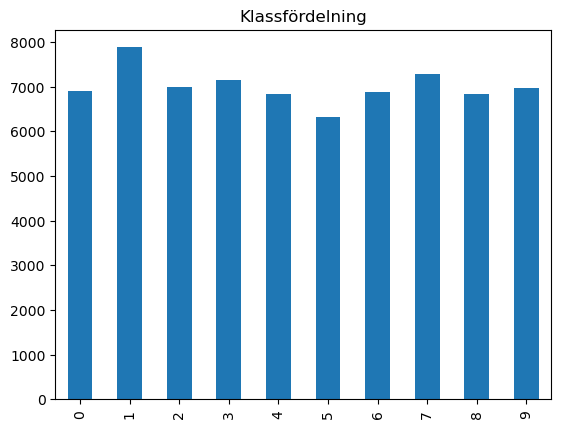

In [6]:
from IPython.display import Image

plot_class_distribution(y) # hur många bilder finns det av varje siffra? Är datasetet balanserat?
display(Image("plots/class_distribution.png"))


Saved to plots/pixel_distribution.png


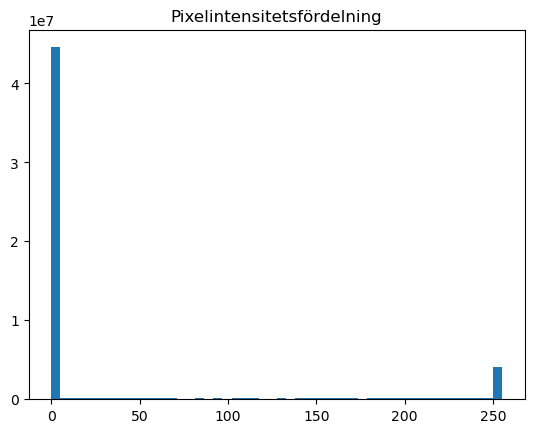

In [7]:
plot_pixel_distribution(X) # hur många pixlar för alla bilder
display(Image("plots/pixel_distribution.png"))


## Visualisera alla. Genomsnittlig bild per siffra


Saved to plots/average_digit_0.png
Saved to plots/average_digit_1.png
Saved to plots/average_digit_2.png
Saved to plots/average_digit_3.png
Saved to plots/average_digit_4.png
Saved to plots/average_digit_5.png
Saved to plots/average_digit_6.png
Saved to plots/average_digit_7.png
Saved to plots/average_digit_8.png
Saved to plots/average_digit_9.png


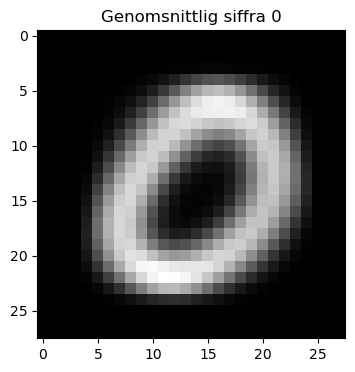

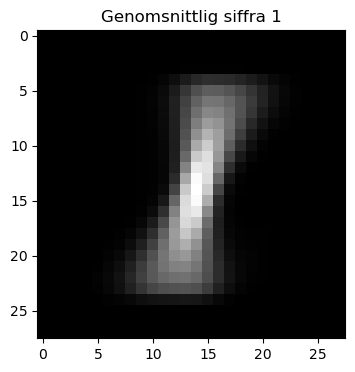

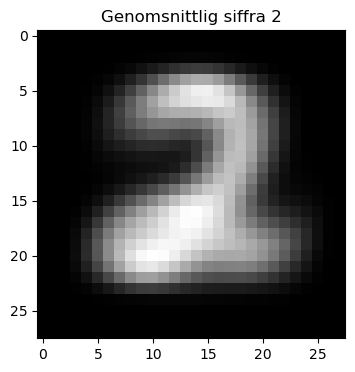

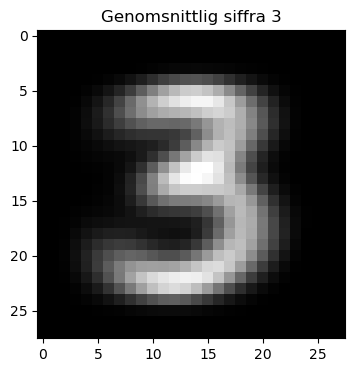

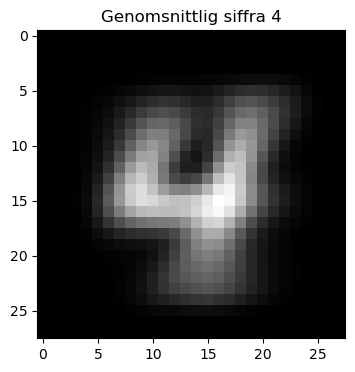

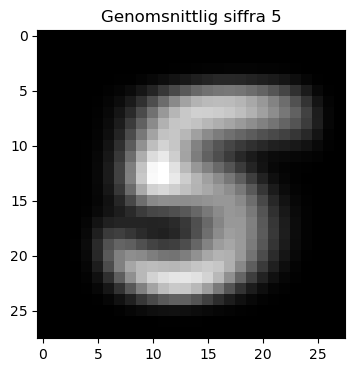

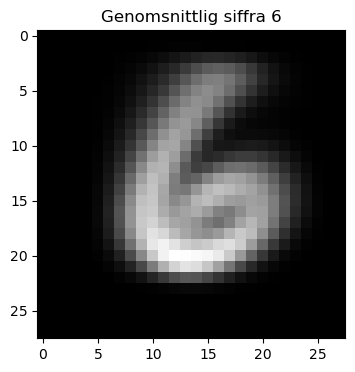

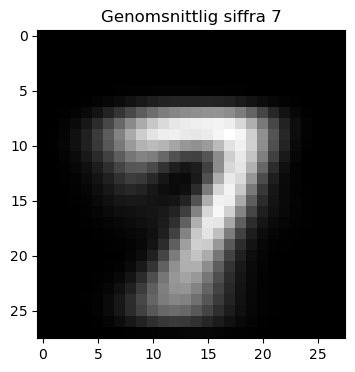

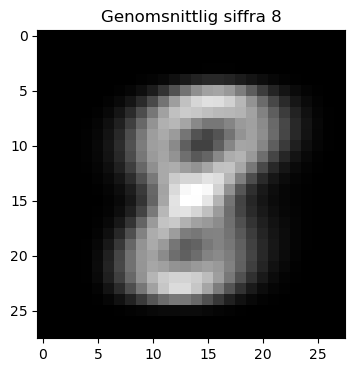

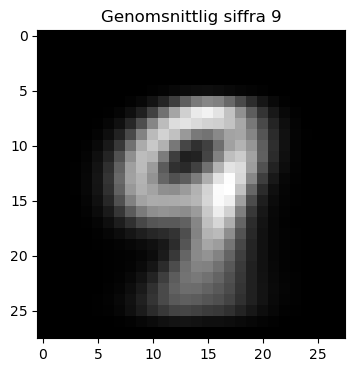

In [8]:
plot_average_digits(X, y) # Genomsnittlig bild för varje siffra, visar typiska mönster och variationer inom klasserna.
# Visa alla sparade genomsnittsbilderna
for digit in np.unique(y):
    display(Image(f"plots/average_digit_{digit}.png"))


## Dela upp data i träning, validering, test


In [9]:
X_train, X_test, y_train, y_test = prepare_data(X, y)


## Steg Träning:

### Om multiklassstrategier för Logistic Regression
Vi använder **One-vs-Rest (OvR)** för Logistic Regression: en binär LR-modell tränas för varje klass mot alla andra. Svc använder i grunden OvO för multiklass. CNN med softmax gör multiklass direkt, utan OvO/OvR-wrapper.

**Varför Multinomial kan vara bättre för LR:** Multinomial LR optimerar alla klasserna samtidigt direkt (som softmax) istället för att träna K separata modeller. Det kan ge:
- Bättre kalibrerade sannolikheter mellan klasser
- Mindre minnesanvändning
- Potentiellt bättre generalisering


In [10]:
lr_ovr_model = train_logistic_regression(X_train, y_train, strategy="ovr")
svc_model = train_or_load_svc(X_train, y_train)


Loading SVC model from file...


### Om modellnamn i Keras-sammanfattning
Här kallar vi vår cnn modell explicit för "Mnist_CNN", för att undvika namn som "sequential_1", som det kommer att heta om vi låter bli sätta namn på den.

Hur man läser sammanfattningstabellen:
- Lager (typ): varje operation i nätverket, såsom Conv2D, MaxPooling2D, Flatten, Dense.
- Output Shape: tensorformen efter det lagret.
- Param #: antal träningsbara parametrar i lagret.
- Totala parametrar / Träningsbara parametrar: modellens kapacitet och vad som uppdateras under träning.

Denna tabell förklarar arkitekturens storlek/komplexitet, medan förvirringsmatrisen och F1/noggrannhet förklarar prediktionskvaliteten.


In [11]:
%pip install tensorflow -q
import tensorflow as tf

model_cnn = build_cnn()
history, X_train_cnn = train_cnn(model_cnn, X_train, y_train)


Note: you may need to restart the kernel to use updated packages.


c:\Users\alexa\.conda\envs\CondaPython3_13_lab12\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Mnist_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9157 - loss: 0.2829 - val_accuracy: 0.9705 - val_loss: 0.0882
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9730 - loss: 0.0876 - val_accuracy: 0.9833 - val_loss: 0.0530
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9799 - loss: 0.0657 - val_accuracy: 0.9855 - val_loss: 0.0457
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9831 - loss: 0.0538 - val_accuracy: 0.9872 - val_loss: 0.0434
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9850 - loss: 0.0468 - val_accuracy: 0.9880 - val_loss: 0.0388
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9872 - loss: 0.0397 - val_accuracy: 0.9887 - val_loss: 0.0375
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9887 - val_loss: 0.0353
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9892 - loss: 0.0334 - val_accu

## Steg Utvärdering:


In [12]:
scores_lr_ovr = evaluate_sklearn_model(lr_ovr_model, X_test, y_test, "Logistic Regression (OvR)")
scores_svc = evaluate_sklearn_model(svc_model, X_test, y_test, "SVC")
scores_cnn = evaluate_cnn(model_cnn, X_test, y_test, name="CNN")

comparison_df = pd.DataFrame([
    scores_lr_ovr,
    scores_svc,
    scores_cnn,
]).set_index("modell")
display(comparison_df.sort_values("f1_macro", ascending=False))



=== Logistic Regression (OvR) ===
accuracy: 0.9169
f1_macro: 0.9157
f1_weighted: 0.9165
balanced_accuracy: 0.9157
log_loss: 0.3585
top_3_accuracy: 0.9813

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.90      0.90      1380
           3       0.90      0.89      0.89      1433
           4       0.91      0.93      0.92      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.94      1503
           8       0.89      0.85      0.87      1357
           9       0.90      0.88      0.89      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

Saved to plots/confusion_matrix_Logistic_Regression_OvR.png



,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,log_loss,top_3_accuracy
modell,,,,,,,,
CNN,0.992071,0.991960,0.992071,0.991960,0.992013,0.992071,0.025155,0.999571
SVC,0.976429,0.976267,0.976361,0.976267,0.976296,0.976407,NaN,NaN
Logistic Regression (OvR),0.916857,0.915712,0.915829,0.915712,0.915666,0.916546,0.358494,0.981286


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>


=== Överanpassningskontroll: Logistic Regression (OvR) ===
train_accuracy: 0.9278 | test_accuracy: 0.9169 | gap: 0.0110
train_f1_macro: 0.9268 | test_f1_macro: 0.9157 | gap: 0.0111

=== Överanpassningskontroll: SVC ===
train_accuracy: 0.9899 | test_accuracy: 0.9764 | gap: 0.0135
train_f1_macro: 0.9899 | test_f1_macro: 0.9763 | gap: 0.0136

=== Överanpassningskontroll: CNN ===
final_train_accuracy: 0.9909 | final_val_accuracy: 0.9910 | gap: -0.0000
final_train_loss: 0.0271 | final_val_loss: 0.0298 | gap: 0.0028
Saved to plots/cnn_training_curves.png


,train_accuracy,test_accuracy,gap_accuracy,train_f1_macro,test_f1_macro,gap_f1_macro,train_loss,val_loss,gap_loss
modell,,,,,,,,,
Logistic Regression (OvR),0.927839,0.916857,0.010982,0.926808,0.915666,0.011143,NaN,NaN,NaN
SVC,0.989946,0.976429,0.013518,0.989920,0.976296,0.013624,NaN,NaN,NaN
CNN,0.990937,NaN,-0.000045,NaN,NaN,NaN,0.027081,0.029843,0.002762


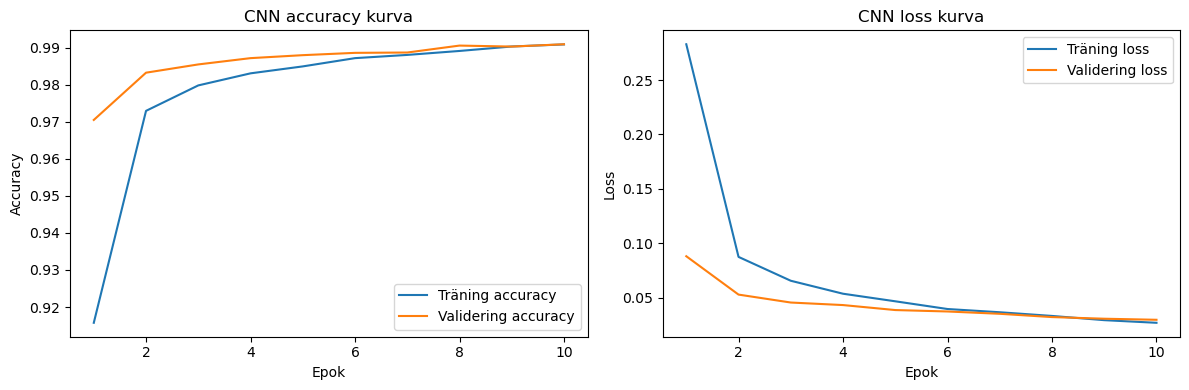

In [13]:
overfit_lr_ovr = evaluate_overfitting_sklearn(
    lr_ovr_model, X_train, y_train, X_test, y_test, "Logistic Regression (OvR)"
)
overfit_svc = evaluate_overfitting_sklearn(
    svc_model, X_train, y_train, X_test, y_test, "SVC"
)
overfit_cnn = evaluate_overfitting_cnn(history, name="CNN")

overfit_df = pd.DataFrame([
    overfit_lr_ovr,
    overfit_svc,
    overfit_cnn,
]).set_index("modell")
display(overfit_df)

# Visa sparade plots
display(Image("plots/cnn_training_curves.png"))


## Överanpassningsdiagnostik
En modell kan se bra ut på testmått men ändå vara överanpassad.
Vi jämför därför träningsprestation mot test/valideringsprestation:
- För sklearn-modeller: train-vs-test accuracy och F1 macro gaps.
- För CNN: train-vs-validation accuracy/loss kurvor och slutliga gaps.

Tumregel:
- Små gaps indikerar bra generalisering.
- Stora positiva train-minus-test/train-minus-val gaps indikerar överanpassning.
